# Segmentación de conductores para aseguradora

Importar librerías

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Cargar el dataset

In [4]:
df = pd.read_csv("conductores_kmeans.csv")
df.head()

,edad,años_experiencia,multas,km_anuales,siniestros
0,56,4,0,17843.604595,0
1,69,36,0,10676.243654,0
2,46,37,1,24112.310116,0
3,32,29,1,18950.355072,0
4,60,8,1,3837.312000,0


EDA

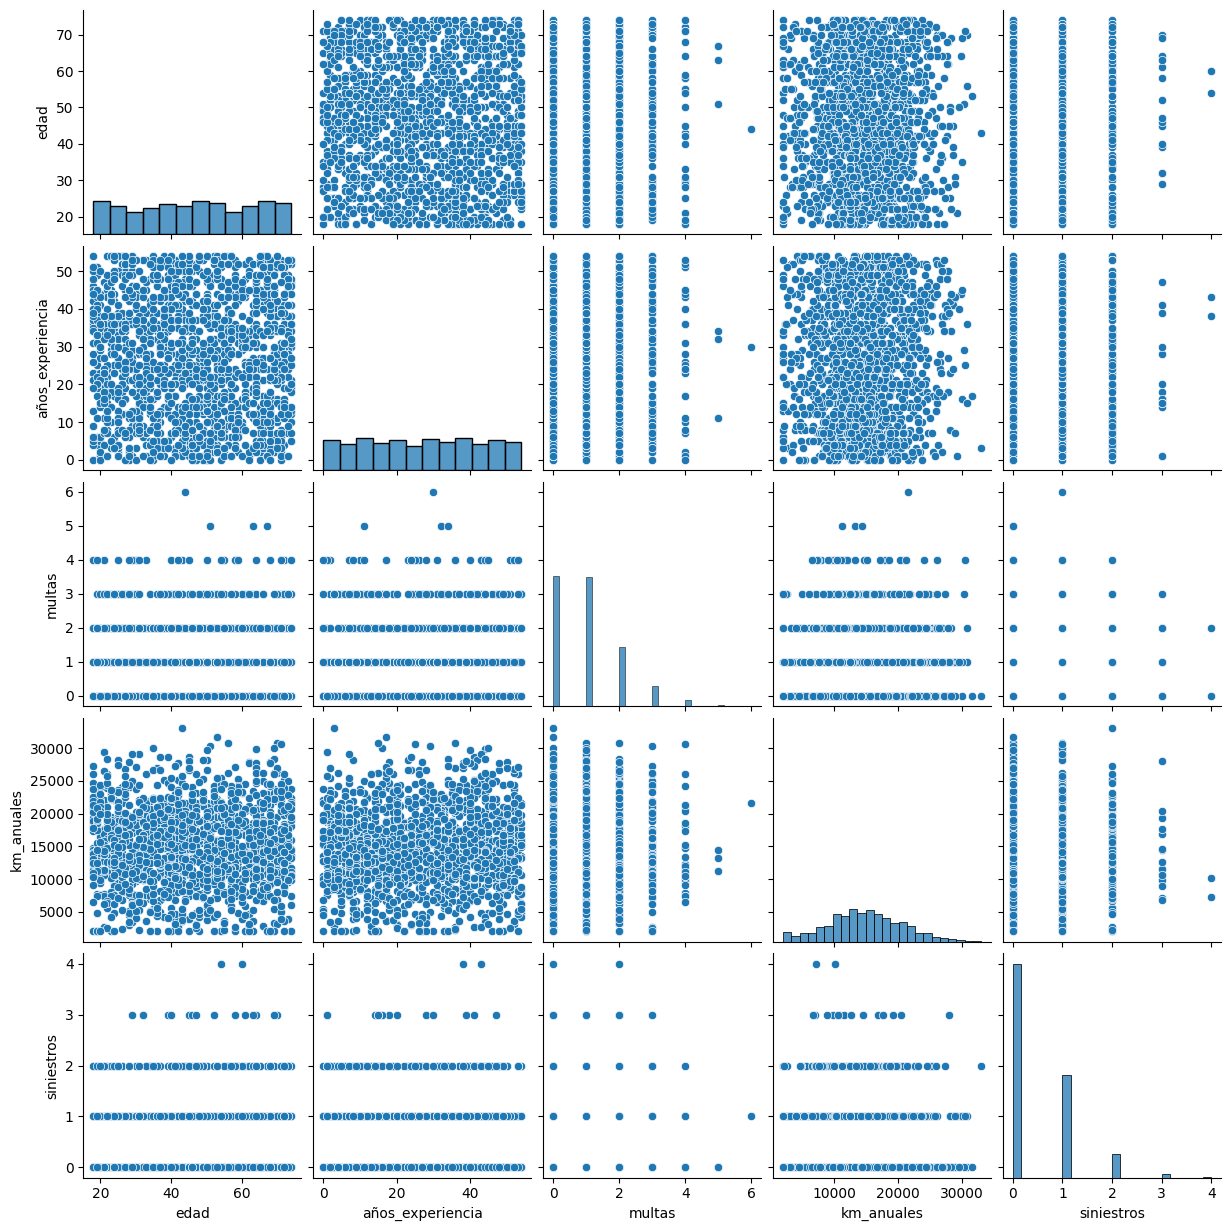

In [5]:
df.describe()
sns.pairplot(df)


Escalado

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)


Método del codo

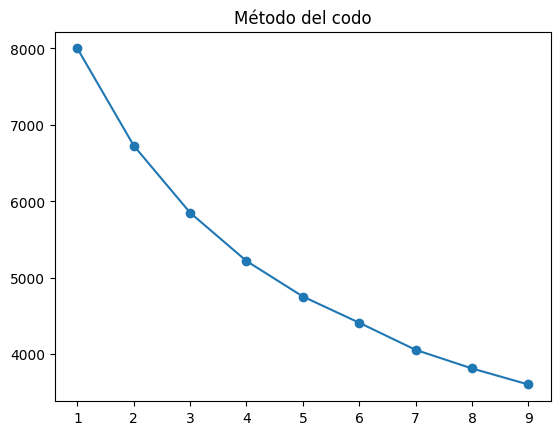

In [7]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(df_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.title("Método del codo")
plt.show()


Entrenamiento final

In [8]:
kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(df_scaled)


Interpretación

In [9]:
df.groupby("cluster").mean()


,edad,años_experiencia,multas,km_anuales,siniestros
cluster,,,,,
0,46.875510,26.224490,0.542857,14728.822558,1.283673
1,45.902174,26.828804,0.512228,14809.996213,0.000000
2,45.994652,27.606952,2.422460,15022.333637,0.320856


Visualización

<Axes: xlabel='km_anuales', ylabel='siniestros'>

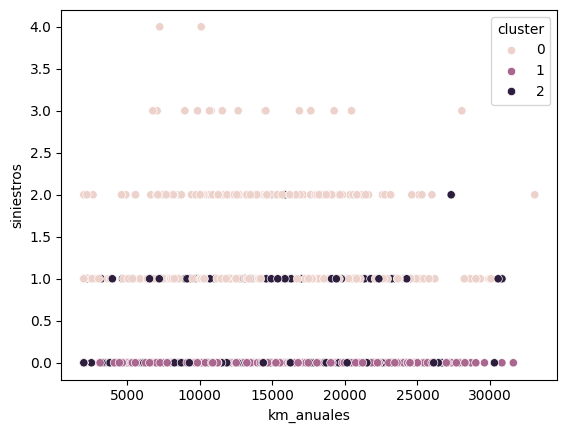

In [10]:
sns.scatterplot(data=df, x="km_anuales", y="siniestros", hue="cluster")
